# Load the data

In [56]:
import pandas as pd 

import json 

# Show all rows
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', None) # Show all columns
pd.set_option('display.width', 1000) # Increase width for wide DataFrames
pd.set_option('display.max_colwidth', 1000) # Increase max column width

path = "/data/gpfs/projects/punim2219/LM_with_SWOW/kabir/Data/output/WV_answers.json"

data = json.load(open(path, 'r'))
df = pd.DataFrame(data)
df.head()

,question,survey_scores,generated_choice,generated_category,choice_logprobs,choice_logprobs_normalized_content,em_score,answer
0,"For each of the following aspects, indicate how important it is in your life. Would you say it is very important, rather important, not very important or not important at all? – Family","{'1': 0.8931739298110297, '2': 0.08522946394138065, '3': 0.018511376783648285, '4': 0.0030852294639413806}",1,Very important,"{'1': -0.554308295249939, '2': -1.554308295249939, '3': -2.1168084144592285, '4': -2.3668084144592285}","{'Very important': 0.5744695518265275, 'Rather important': 0.21133553769595187, 'Not very important': 0.1204153452797993, 'Not at all important': 0.0937795651977213}",0.159352,NaN
1,"For each of the following aspects, indicate how important it is in your life. Would you say it is very important, rather important, not very important or not important at all? – Friends","{'1': 0.4823848238482385, '2': 0.41308555942702285, '3': 0.09601238869531553, '4': 0.008517228029423151}",1,Very important,"{'1': -0.6846570372581482, '2': -1.497157096862793, '3': -1.934657096862793, '4': -2.059657096862793}","{'Very important': 0.5042631302241375, 'Rather important': 0.22376539427256906, 'Not very important': 0.14447379707764046, 'Not at all important': 0.1274976784256531}",0.094660,NaN
2,"For each of the following aspects, indicate how important it is in your life. Would you say it is very important, rather important, not very important or not important at all? – Leisure time","{'1': 0.390007745933385, '2': 0.49806351665375675, '3': 0.10379550735863671, '4': 0.008133230054221533}",1,Very important,"{'1': -1.0782287120819092, '2': -1.4532287120819092, '3': -1.5157287120819092, '4': -1.5782287120819092}","{'Very important': 0.34019756018144737, 'Rather important': 0.23381413578355534, 'Not very important': 0.21964805342551566, 'Not at all important': 0.2063402506094816}",0.157030,NaN
3,"For each of the following aspects, indicate how important it is in your life. Would you say it is very important, rather important, not very important or not important at all? – Politics","{'1': 0.14063714063714064, '2': 0.41647241647241645, '3': 0.37101787101787104, '4': 0.07187257187257187}",2,Rather important,"{'1': -1.2807222604751587, '2': -1.1557222604751587, '3': -1.5307222604751587, '4': -1.6557222604751587}","{'Very important': 0.2778365467729137, 'Rather important': 0.31483005318115603, 'Not very important': 0.21637932019260017, 'Not at all important': 0.19095407985333004}",0.097412,NaN
4,"For each of the following aspects, indicate how important it is in your life. Would you say it is very important, rather important, not very important or not important at all? – Work","{'1': 0.3809154383242824, '2': 0.44414274631497286, '3': 0.11404189294026378, '4': 0.06089992242048099}",1,Very important,"{'1': -0.8956977128982544, '2': -1.1456977128982544, '3': -1.9581977128982544, '4': -2.020697593688965}","{'Very important': 0.40832258749518185, 'Rather important': 0.3180019508869899, 'Not very important': 0.14111251030663743, 'Not at all important': 0.13256295131119072}",0.049367,NaN


In [57]:
df.iloc[0]['survey_scores'].keys()

dict_keys(['1', '2', '3', '4'])

In [58]:
def identify_problematic_rows(df):
    # Find rows where survey_scores is not a dictionary
    non_dict_rows = df[~df['survey_scores'].apply(lambda x: isinstance(x, dict))]
    # Display these rows
    print(non_dict_rows)
    # Or to see just the survey_scores values
    print(df.loc[~df['survey_scores'].apply(lambda x: isinstance(x, dict)), 'survey_scores'])
    
def count_keys(x):
    if isinstance(x, dict):
        return len(x.keys())
    else:
        return 0  # or any other default value or handling you prefer

df['num_choices'] = df['survey_scores'].apply(count_keys)
# df['num_choices'] = df['survey_scores'].apply(lambda x: len(x.keys()))
df['num_choices']


0       4
1       4
2       4
3       4
4       4
       ..
240     2
241     4
242     5
243    10
244    10
Name: num_choices, Length: 245, dtype: int64

num_choices
0          NaN
2     0.209151
3     0.138562
4     0.085287
5     0.066597
6     0.045243
7     0.054759
8     0.065616
10    0.039064
11    0.028419
12    0.017870
13    0.101003
Name: em_score, dtype: float64


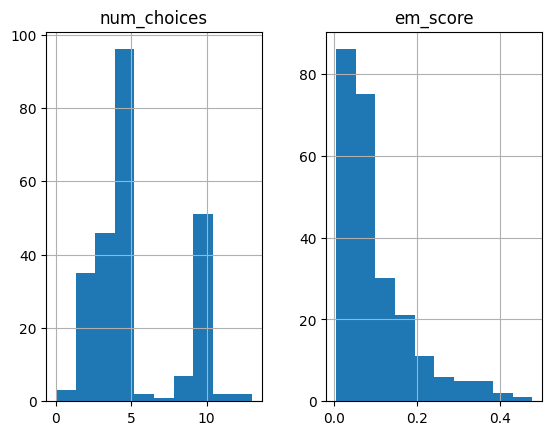

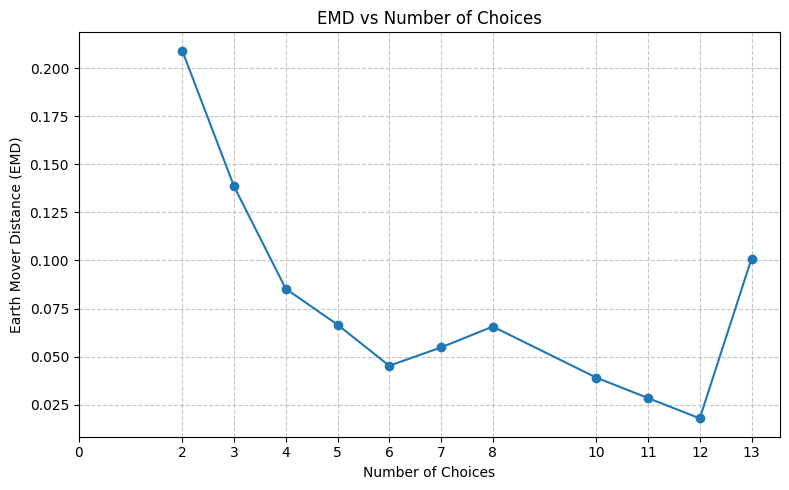

In [59]:
df[['num_choices', 'em_score']].hist()
# Group by num_choices and calculate mean of em_score
avg_em_by_choices = df.groupby('num_choices')['em_score'].mean()

# Display the results
print(avg_em_by_choices)

# Create quick visualization
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
avg_em_by_choices.plot(marker='o')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel('Number of Choices')
plt.ylabel('Earth Mover Distance (EMD)')
plt.title('EMD vs Number of Choices')
plt.xticks(avg_em_by_choices.index)
plt.tight_layout()
plt.show()

## Distribution on the numbner of choice

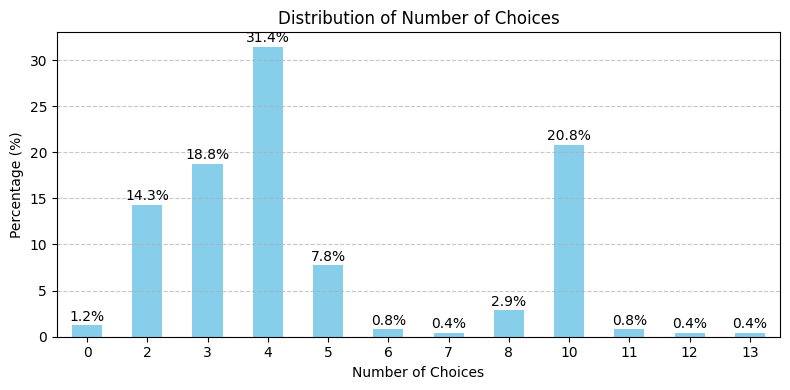

In [60]:
# df['num_choices'].value_counts(normalize=True).sort_index()
# Get value counts sorted by index and convert to percentage
counts = df['num_choices'].value_counts(normalize=True).sort_index() * 100

# Create histogram plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
counts.plot(kind='bar', color='skyblue')
plt.xlabel('Number of Choices')
plt.ylabel('Percentage (%)')
plt.title('Distribution of Number of Choices')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)  # Keep x labels horizontal

# Add percentage labels on top of each bar
for i, v in enumerate(counts):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

## Examples of earth_mover_distance with different number of choices

In [61]:
for name, group in df.groupby("num_choices"): 
    display(name, group[['num_choices','question', 'survey_scores', 'choice_logprobs_normalized_content', 'earth_mover_distance']])
    display(group['earth_mover_distance'].mean())
    

0

,num_choices,question,survey_scores,choice_logprobs_normalized_content,em_score
222,0,"Can you tell me your year of birth, please?. Numeric variable - year of birth",NaN,NaN,NaN
223,0,This means you are XX years old?. Numeric variable - numbers of years,NaN,NaN,NaN
227,0,What language do you normally speak at home?,NaN,NaN,NaN


nan

2

,num_choices,question,survey_scores,choice_logprobs_normalized_content,em_score
6,2,"Here is a list of qualities that children can be encouraged to learn at home. Which, if any, do you consider to be especially important? Please choose up to five. – Good manners","{'1': 0.49691358024691357, '2': 0.5030864197530864}","{'Not mentioned': 0.01912403685570912, 'Important': 0.9808759631442909}",0.477790
7,2,"Here is a list of qualities that children can be encouraged to learn at home. Which, if any, do you consider to be especially important? Please choose up to five. – Independence","{'1': 0.5532407407407407, '2': 0.44675925925925924}","{'Not mentioned': 0.01912403685570912, 'Important': 0.9808759631442909}",0.427635
8,2,"Here is a list of qualities that children can be encouraged to learn at home. Which, if any, do you consider to be especially important? Please choose up to five. – Hard work","{'1': 0.6840277777777778, '2': 0.3159722222222222}","{'Not mentioned': 0.02033235323135295, 'Important': 0.9796676467686469}",0.295640
9,2,"Here is a list of qualities that children can be encouraged to learn at home. Which, if any, do you consider to be especially important? Please choose up to five. – Feeling of responsibility","{'1': 0.5887345679012346, '2': 0.4112654320987654}","{'Not mentioned': 0.014957087732036361, 'Important': 0.9850429122679635}",0.396308
10,2,"Here is a list of qualities that children can be encouraged to learn at home. Which, if any, do you consider to be especially important? Please choose up to five. – Imagination","{'1': 0.3395061728395062, '2': 0.6604938271604939}","{'Not mentioned': 0.02033235323135295, 'Important': 0.9796676467686469}",0.319174
...,...,...,...,...,...
150,2,With which one of the following statements do you agree most? The meaning of religion is…,"{'1': 0.2209165687426557, '2': 0.7790834312573442}","{'Follow religious norms and ceremonies': 0.9196425372343817, 'Do good to other people': 0.08035746276561836}",0.140559
151,2,And with which of the following statements do you agree most? The meaning of religion is…,"{'1': 0.24201813165155694, '2': 0.757981868348443}","{'Make sense of life after death': 0.8991213806488609, 'Make sense of life in this world': 0.10087861935113906}",0.141140
221,2,Respondent’s sex,"{'1': 0.5354391371340523, '2': 0.4645608628659476}","{'Male': 0.7981867753392728, 'Female': 0.20181322466072707}",0.262748
224,2,Were you born in this country or are you an immigrant?,"{'1': 0.8943217665615142, '2': 0.1056782334384858}","{'I am born in this country': 0.8438951104066293, 'I am an immigrant to this country (born outside this country)': 0.15610488959337065}",0.050427


...

,num_choices,question,survey_scores,choice_logprobs_normalized_content,em_score
236,12,To which of the following occupational groups do you belong?,"{'0': 0.008917197452229299, '1': 0.36942675159235666, '2': 0.06496815286624204, '3': 0.1070063694267516, '4': 0.0980891719745223, '5': 0.11910828025477707, '6': 0.09235668789808917, '7': 0.04331210191082802, '8': 0.050955414012738856, '9': 0.009554140127388535, '10': 0.0025477707006369425, '11': 0.03375796178343949}","{'Never had a job': 0.10544123661290994, 'Professional and technical (for example: doctor, teacher, engineer, artist, accountant, nurse)': 0.3051042982403024, 'Higher administrative (for example: banker, executive in big business, high government official, union official)': 0.09305156471558246, 'Clerical (for example: secretary, clerk, office manager, civil servant, bookkeeper': 0.06395334280374414, 'Sales (for example: sales manager, shop owner, shop assistant, insurance agent, buyer)': 0.04980691345558993, 'Service (for example: restaurant owner, police officer, waitress, barber, caretaker)': 0.08211771764215155, 'Skilled worker (for example: foreman, motor mechanic, printer, seamstress, tool and die maker, electrician)': 0.025044488886736375, 'Semi-skilled worker (for example: bricklayer, bus driver, cannery worker, carpenter, sheet metal worker, baker)': 0.05643862693423503, 'Unskilled worker (for example: labourer, porter, unskilled factory worker, cleaner)': 0.093051564715582...",0.01787


0.01787014653666135

13

,num_choices,question,survey_scores,choice_logprobs_normalized_content,em_score
229,13,"Have you had children? If yes, how many?","{'0': 0.3684004692999609, '1': 0.15526007039499412, '2': 0.24716464606961283, '3': 0.12592882283926476, '4': 0.05866249511145874, '5': 0.028549080954243255, '6': 0.009777082518576457, '7': 0.0023464998044583495, '8': 0.0011732499022291747, '9': 0.00039108330074305825, '10': 0.0007821666014861165, '12': 0.0011732499022291747, '15': 0.00039108330074305825}","{'No children': 0.02293856999533268, '1 child': 0.759621135320014, '2 children': 0.10280353843726714, '3 children': 0.031353307785891536, '4 children': 0.020885805655991563, '5 children': 0.03552795221611108, '6 children': 0.0059838849334004456, '25.- 7 or more children': 0.020885805655991563}",0.101003


0.10100283944567376

## Distribution of overall earth mover distance

<Axes: >

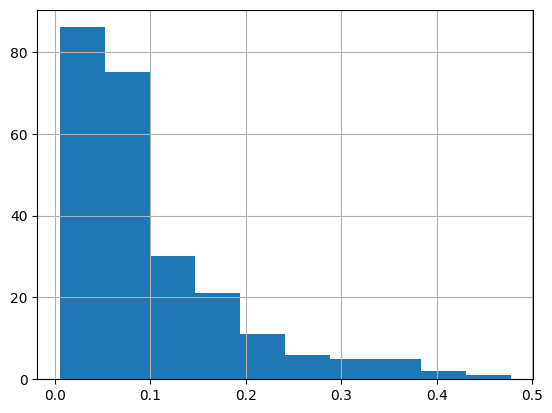

In [62]:
df['earth_mover_distance'].hist()

# Check majority votes

In [66]:
df['generated_choice'].value_counts()

generated_choice
1    163
2     44
8     23
3      5
0      4
5      1
4      1
7      1
Name: count, dtype: int64

In [63]:
from sklearn.metrics import accuracy_score


print(df.columns)
display(df.head())

df = df.query("num_choices>0")

df['human_category_majority'] = df['survey_scores'].apply(lambda x: max(x.items(), key=lambda item: item[1])[0] if isinstance(x, dict) else None)
display(df.head())

# df['human_category_majority'] = df['human_category_majority'].astype(float)
accuracy = accuracy_score(df['human_category_majority'], df['generated_choice'])

print(f"Accuracy: {accuracy:.4f}")

Index(['question', 'survey_scores', 'generated_choice', 'generated_category', 'choice_logprobs', 'choice_logprobs_normalized_content', 'em_score', 'answer', 'num_choices'], dtype='object')


,question,survey_scores,generated_choice,generated_category,choice_logprobs,choice_logprobs_normalized_content,em_score,answer,num_choices
0,"For each of the following aspects, indicate how important it is in your life. Would you say it is very important, rather important, not very important or not important at all? – Family","{'1': 0.8931739298110297, '2': 0.08522946394138065, '3': 0.018511376783648285, '4': 0.0030852294639413806}",1,Very important,"{'1': -0.554308295249939, '2': -1.554308295249939, '3': -2.1168084144592285, '4': -2.3668084144592285}","{'Very important': 0.5744695518265275, 'Rather important': 0.21133553769595187, 'Not very important': 0.1204153452797993, 'Not at all important': 0.0937795651977213}",0.159352,NaN,4
1,"For each of the following aspects, indicate how important it is in your life. Would you say it is very important, rather important, not very important or not important at all? – Friends","{'1': 0.4823848238482385, '2': 0.41308555942702285, '3': 0.09601238869531553, '4': 0.008517228029423151}",1,Very important,"{'1': -0.6846570372581482, '2': -1.497157096862793, '3': -1.934657096862793, '4': -2.059657096862793}","{'Very important': 0.5042631302241375, 'Rather important': 0.22376539427256906, 'Not very important': 0.14447379707764046, 'Not at all important': 0.1274976784256531}",0.094660,NaN,4
2,"For each of the following aspects, indicate how important it is in your life. Would you say it is very important, rather important, not very important or not important at all? – Leisure time","{'1': 0.390007745933385, '2': 0.49806351665375675, '3': 0.10379550735863671, '4': 0.008133230054221533}",1,Very important,"{'1': -1.0782287120819092, '2': -1.4532287120819092, '3': -1.5157287120819092, '4': -1.5782287120819092}","{'Very important': 0.34019756018144737, 'Rather important': 0.23381413578355534, 'Not very important': 0.21964805342551566, 'Not at all important': 0.2063402506094816}",0.157030,NaN,4
3,"For each of the following aspects, indicate how important it is in your life. Would you say it is very important, rather important, not very important or not important at all? – Politics","{'1': 0.14063714063714064, '2': 0.41647241647241645, '3': 0.37101787101787104, '4': 0.07187257187257187}",2,Rather important,"{'1': -1.2807222604751587, '2': -1.1557222604751587, '3': -1.5307222604751587, '4': -1.6557222604751587}","{'Very important': 0.2778365467729137, 'Rather important': 0.31483005318115603, 'Not very important': 0.21637932019260017, 'Not at all important': 0.19095407985333004}",0.097412,NaN,4
4,"For each of the following aspects, indicate how important it is in your life. Would you say it is very important, rather important, not very important or not important at all? – Work","{'1': 0.3809154383242824, '2': 0.44414274631497286, '3': 0.11404189294026378, '4': 0.06089992242048099}",1,Very important,"{'1': -0.8956977128982544, '2': -1.1456977128982544, '3': -1.9581977128982544, '4': -2.020697593688965}","{'Very important': 0.40832258749518185, 'Rather important': 0.3180019508869899, 'Not very important': 0.14111251030663743, 'Not at all important': 0.13256295131119072}",0.049367,NaN,4


,question,survey_scores,generated_choice,generated_category,choice_logprobs,choice_logprobs_normalized_content,em_score,answer,num_choices,human_category_majority
0,"For each of the following aspects, indicate how important it is in your life. Would you say it is very important, rather important, not very important or not important at all? – Family","{'1': 0.8931739298110297, '2': 0.08522946394138065, '3': 0.018511376783648285, '4': 0.0030852294639413806}",1,Very important,"{'1': -0.554308295249939, '2': -1.554308295249939, '3': -2.1168084144592285, '4': -2.3668084144592285}","{'Very important': 0.5744695518265275, 'Rather important': 0.21133553769595187, 'Not very important': 0.1204153452797993, 'Not at all important': 0.0937795651977213}",0.159352,NaN,4,1
1,"For each of the following aspects, indicate how important it is in your life. Would you say it is very important, rather important, not very important or not important at all? – Friends","{'1': 0.4823848238482385, '2': 0.41308555942702285, '3': 0.09601238869531553, '4': 0.008517228029423151}",1,Very important,"{'1': -0.6846570372581482, '2': -1.497157096862793, '3': -1.934657096862793, '4': -2.059657096862793}","{'Very important': 0.5042631302241375, 'Rather important': 0.22376539427256906, 'Not very important': 0.14447379707764046, 'Not at all important': 0.1274976784256531}",0.094660,NaN,4,1
2,"For each of the following aspects, indicate how important it is in your life. Would you say it is very important, rather important, not very important or not important at all? – Leisure time","{'1': 0.390007745933385, '2': 0.49806351665375675, '3': 0.10379550735863671, '4': 0.008133230054221533}",1,Very important,"{'1': -1.0782287120819092, '2': -1.4532287120819092, '3': -1.5157287120819092, '4': -1.5782287120819092}","{'Very important': 0.34019756018144737, 'Rather important': 0.23381413578355534, 'Not very important': 0.21964805342551566, 'Not at all important': 0.2063402506094816}",0.157030,NaN,4,2
3,"For each of the following aspects, indicate how important it is in your life. Would you say it is very important, rather important, not very important or not important at all? – Politics","{'1': 0.14063714063714064, '2': 0.41647241647241645, '3': 0.37101787101787104, '4': 0.07187257187257187}",2,Rather important,"{'1': -1.2807222604751587, '2': -1.1557222604751587, '3': -1.5307222604751587, '4': -1.6557222604751587}","{'Very important': 0.2778365467729137, 'Rather important': 0.31483005318115603, 'Not very important': 0.21637932019260017, 'Not at all important': 0.19095407985333004}",0.097412,NaN,4,2
4,"For each of the following aspects, indicate how important it is in your life. Would you say it is very important, rather important, not very important or not important at all? – Work","{'1': 0.3809154383242824, '2': 0.44414274631497286, '3': 0.11404189294026378, '4': 0.06089992242048099}",1,Very important,"{'1': -0.8956977128982544, '2': -1.1456977128982544, '3': -1.9581977128982544, '4': -2.020697593688965}","{'Very important': 0.40832258749518185, 'Rather important': 0.3180019508869899, 'Not very important': 0.14111251030663743, 'Not at all important': 0.13256295131119072}",0.049367,NaN,4,2


Accuracy: 0.3512


In [65]:
df.query("human_category_majority != generated_choice")

,question,survey_scores,generated_choice,generated_category,choice_logprobs,choice_logprobs_normalized_content,em_score,answer,num_choices,human_category_majority
2,"For each of the following aspects, indicate how important it is in your life. Would you say it is very important, rather important, not very important or not important at all? – Leisure time","{'1': 0.390007745933385, '2': 0.49806351665375675, '3': 0.10379550735863671, '4': 0.008133230054221533}",1,Very important,"{'1': -1.0782287120819092, '2': -1.4532287120819092, '3': -1.5157287120819092, '4': -1.5782287120819092}","{'Very important': 0.34019756018144737, 'Rather important': 0.23381413578355534, 'Not very important': 0.21964805342551566, 'Not at all important': 0.2063402506094816}",0.157030,NaN,4,2
4,"For each of the following aspects, indicate how important it is in your life. Would you say it is very important, rather important, not very important or not important at all? – Work","{'1': 0.3809154383242824, '2': 0.44414274631497286, '3': 0.11404189294026378, '4': 0.06089992242048099}",1,Very important,"{'1': -0.8956977128982544, '2': -1.1456977128982544, '3': -1.9581977128982544, '4': -2.020697593688965}","{'Very important': 0.40832258749518185, 'Rather important': 0.3180019508869899, 'Not very important': 0.14111251030663743, 'Not at all important': 0.13256295131119072}",0.049367,NaN,4,2
6,"Here is a list of qualities that children can be encouraged to learn at home. Which, if any, do you consider to be especially important? Please choose up to five. – Good manners","{'1': 0.49691358024691357, '2': 0.5030864197530864}",1,Important,"{'2': -3.9568092823028564, '1': -0.019309287890791893}","{'Not mentioned': 0.01912403685570912, 'Important': 0.9808759631442909}",0.477790,NaN,2,2
10,"Here is a list of qualities that children can be encouraged to learn at home. Which, if any, do you consider to be especially important? Please choose up to five. – Imagination","{'1': 0.3395061728395062, '2': 0.6604938271604939}",1,Important,"{'2': -3.8955419063568115, '1': -0.020541900768876076}","{'Not mentioned': 0.02033235323135295, 'Important': 0.9796676467686469}",0.319174,NaN,2,2
12,"Here is a list of qualities that children can be encouraged to learn at home. Which, if any, do you consider to be especially important? Please choose up to five. – Thrift saving money and things","{'1': 0.26774691358024694, '2': 0.7322530864197531}",1,Important,"{'2': -3.4691390991210938, '1': -0.03163906931877136}","{'Not mentioned': 0.03114382963552641, 'Important': 0.9688561703644736}",0.236603,NaN,2,2
...,...,...,...,...,...,...,...,...,...,...
233,What is the highest educational level that your father has attained?,"{'0': 0.015618221258134491, '2': 0.14837310195227765, '3': 0.3418655097613883, '4': 0.18394793926247288, '5': 0.052928416485900215, '6': 0.1383947939262473, '7': 0.0668112798264642, '8': 0.052060737527114966}",1,Primary education (ISCED 1),"{'0': -2.1554861068725586, '1': -0.530485987663269, '2': -2.2804861068725586, '3': -3.1554861068725586, '4': -3.7804861068725586, '5': -3.4367361068725586, '6': -4.842986106872559, '7': -3.8117361068725586, '8': -2.7179861068725586}","{'Early childhood education (ISCED 0) / no education': 0.11584687134312482, 'Primary education (ISCED 1)': 0.5883190269597657, 'Lower secondary education (ISCED 2)': 0.10223450513442378, 'Upper secondary education (ISCED 3)': 0.04261768229116873, 'Post-secondary non-tertiary education (ISCED 4)': 0.022811601503339454, 'Short-cycle tertiary education (ISCED 5)': 0.03216951433835978, 'Bachelor or equivalent (ISCED 6)': 0.007883478531025124, 'Master or equivalent (ISCED 7)': 0.022109762308667135, 'Doctoral or equivalent (ISCED 8)': 0.06600755759012548}",0.073540,NaN,8,3
238,"When you were 14, to which of the following occupational groups did your father belong?","{'0': 0.006756756756756757, '1': 0.21036036036036035, '2': 0.07117117117117117, '3': 0.03513513513513514, '4': 0.08423423423423423, '5': 0.078828828828828